# Exploratory Data Analysis (EDA)
## E-Commerce Customer Churn Prediction

**Goal:** Understand the data before building ML models. We'll investigate:
1. Dataset overview — shape, types, distributions
2. Churn distribution — how imbalanced is our target?
3. Feature distributions — what does each variable look like?
4. Churn correlations — which features relate to churn?
5. Key insights — what should our model focus on?

In [1]:
# === IMPORTS ===
# pandas: data manipulation (think of it as Excel on steroids)
# matplotlib/seaborn: static charts (publication-quality)
# plotly: interactive charts (hover, zoom, etc.)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visual style — 'whitegrid' gives clean charts with gridlines
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


## 1. Load & Overview
First, let's load our clean dataset and understand its structure.

In [2]:
# Load the clean merged dataset from our pipeline
df = pd.read_csv('../data/clean_dataset.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')
df.head()

Dataset shape: 5000 rows x 20 columns

Column names:
['customer_id', 'age', 'gender', 'city', 'subscription_tier', 'tenure_days', 'total_transactions', 'total_spend', 'avg_transaction_amount', 'max_transaction_amount', 'unique_categories', 'days_since_last_purchase', 'total_tickets', 'resolved_tickets', 'avg_resolution_days', 'ticket_resolution_rate', 'total_reviews', 'avg_rating', 'min_rating', 'churned']


,customer_id,age,gender,city,subscription_tier,tenure_days,total_transactions,total_spend,avg_transaction_amount,max_transaction_amount,unique_categories,days_since_last_purchase,total_tickets,resolved_tickets,avg_resolution_days,ticket_resolution_rate,total_reviews,avg_rating,min_rating,churned
0,CUST_00001,43,Female,Seattle,Basic,617,13,611.49,47.037692,109.31,7,25,4.0,4.0,4.8,1.00,2.0,4.00,4.0,0
1,CUST_00002,35,Male,New York,Premium,450,13,735.39,56.568462,138.22,8,8,1.0,1.0,4.0,1.00,2.0,4.50,4.0,0
2,CUST_00003,56,Male,Houston,Enterprise,503,10,505.27,50.527000,169.97,6,7,1.0,1.0,4.0,1.00,2.0,4.50,4.0,0
3,CUST_00004,32,Male,Chicago,Free,627,15,522.38,34.825333,82.89,8,120,4.0,3.0,5.0,0.75,1.0,2.00,2.0,0
4,CUST_00005,40,Male,Seattle,Free,642,13,690.72,53.132308,155.81,6,192,4.0,4.0,5.2,1.00,3.0,2.33,2.0,1


In [3]:
# .describe() gives summary statistics for ALL numeric columns at once
# Key things to look at: min/max (outliers?), mean vs median (skewed?), std (spread?)
df.describe().round(2)

,age,tenure_days,total_transactions,total_spend,avg_transaction_amount,max_transaction_amount,unique_categories,days_since_last_purchase,total_tickets,resolved_tickets,avg_resolution_days,ticket_resolution_rate,total_reviews,avg_rating,min_rating,churned
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,38.05,454.56,13.86,859.02,61.47,184.62,7.46,33.86,1.85,1.45,3.02,0.65,2.48,2.79,2.16,0.28
std,11.47,159.27,4.05,343.13,15.98,78.36,1.48,37.53,1.40,1.16,2.21,0.41,1.73,1.58,1.51,0.45
min,18.00,181.00,1.00,26.64,17.63,22.49,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,315.00,11.00,608.75,50.34,125.19,7.00,9.00,1.00,1.00,1.00,0.33,1.00,2.00,1.00,0.00
50%,38.00,452.00,14.00,831.00,59.78,169.24,8.00,22.00,2.00,1.00,3.30,0.80,2.00,3.00,2.00,0.00
75%,46.00,595.00,17.00,1083.54,70.88,231.57,9.00,45.00,3.00,2.00,5.00,1.00,4.00,4.00,3.00,1.00
max,75.00,731.00,27.00,2314.30,298.27,350.94,10.00,484.00,7.00,6.00,7.00,1.00,5.00,5.00,5.00,1.00


In [4]:
# Check for missing values — important to know BEFORE modeling
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

Missing values per column:
No missing values!


## 2. Target Variable: Churn Distribution

**Why this matters:** If churn is very imbalanced (e.g., 95% not churned, 5% churned),
a model that always predicts "not churned" gets 95% accuracy — but is useless!
We need to check this to choose the right evaluation metrics and possibly rebalance.

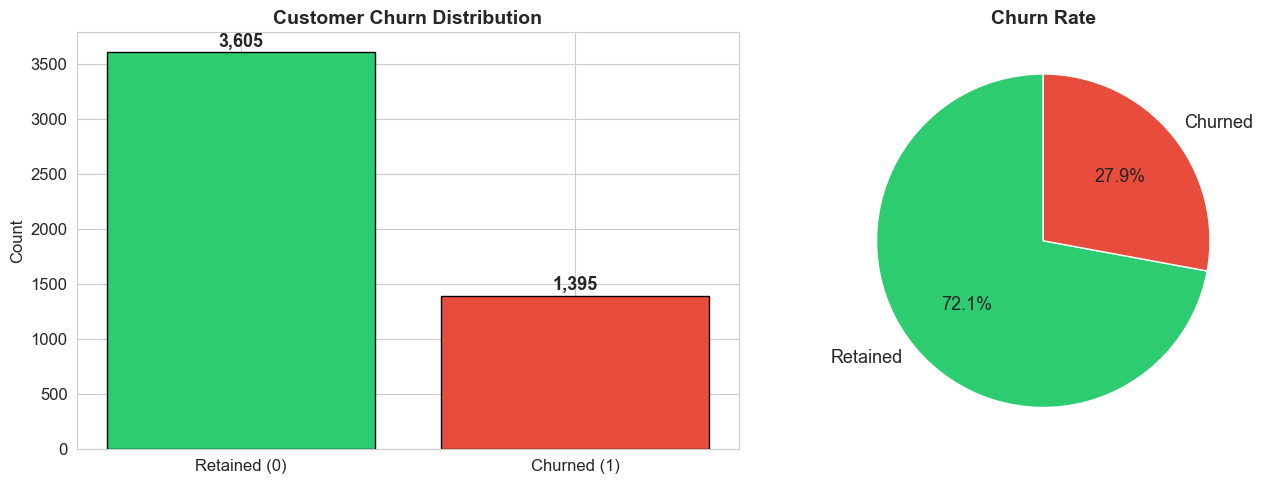


Churn rate: 27.9%
This is a moderately imbalanced dataset — manageable with standard techniques.


In [5]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = df['churned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChurn rate: {df["churned"].mean():.1%}')
print(f'This is a moderately imbalanced dataset — manageable with standard techniques.')

## 3. Feature Distributions

Let's visualize every numeric feature, split by churn status.
This immediately shows us which features differ between churned and retained customers.

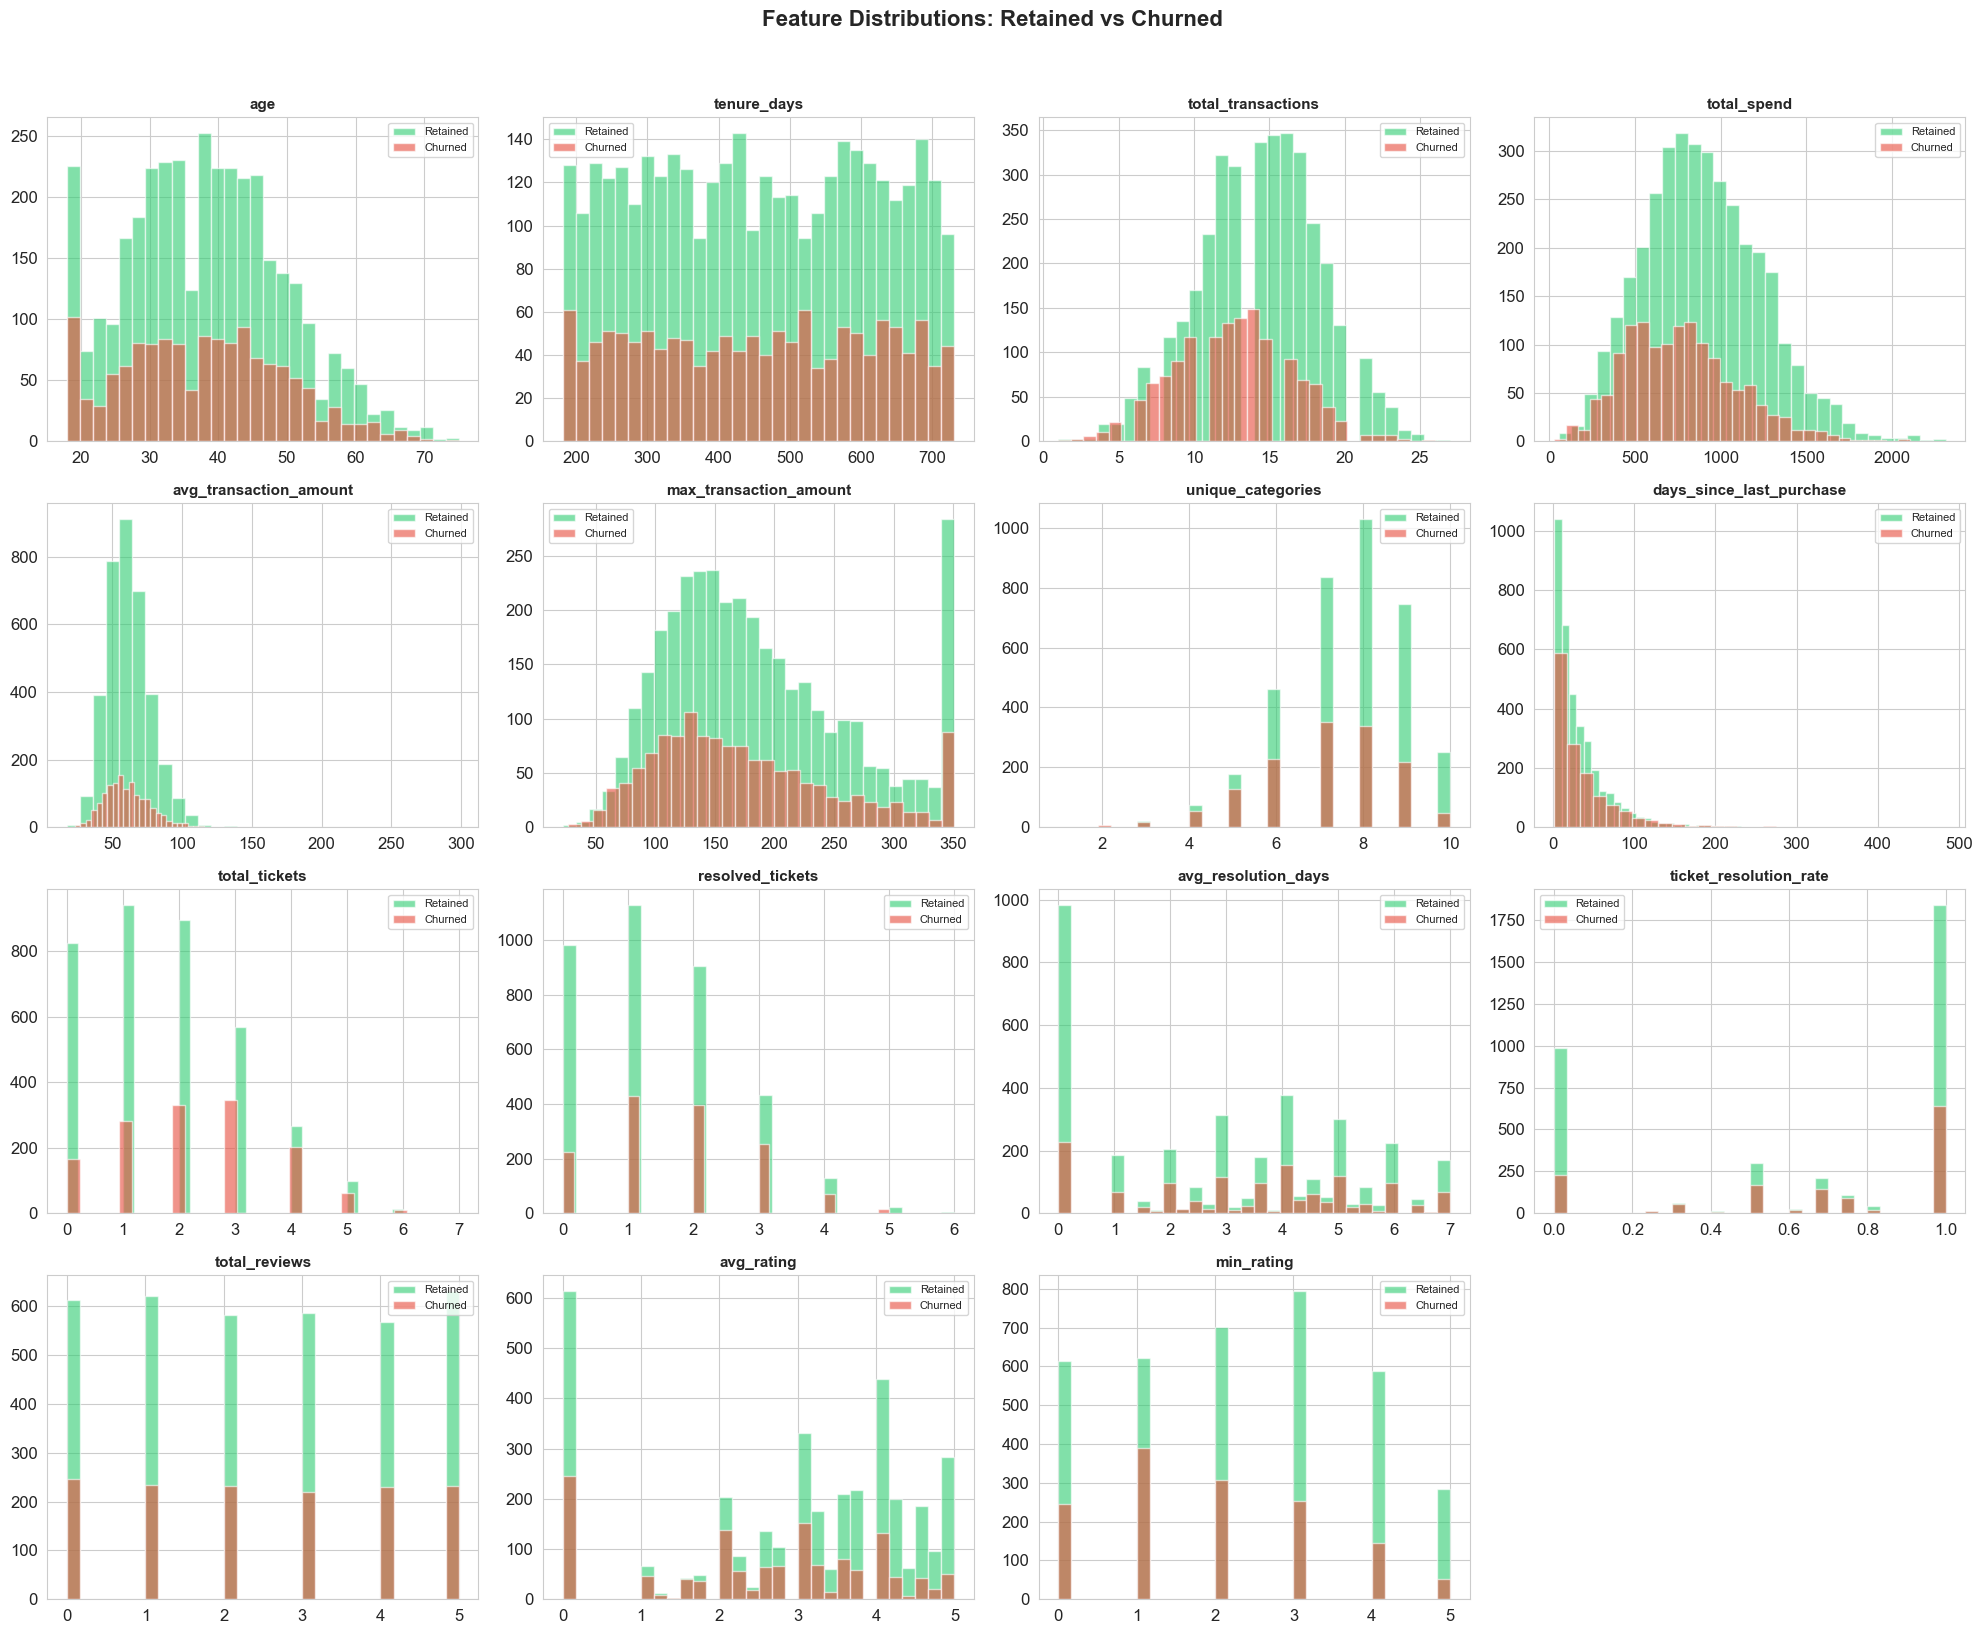

In [6]:
# Numeric columns (excluding IDs and the target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('churned').tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # Plot histogram for retained vs churned, overlapping
    df[df['churned'] == 0][col].hist(ax=ax, bins=30, alpha=0.6, color='#2ecc71', label='Retained')
    df[df['churned'] == 1][col].hist(ax=ax, bins=30, alpha=0.6, color='#e74c3c', label='Churned')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Retained vs Churned', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

**Correlation heatmap** shows linear relationships between features.
Values range from -1 (perfect negative) to +1 (perfect positive).
Look at the 'churned' row to see which features correlate with churn.

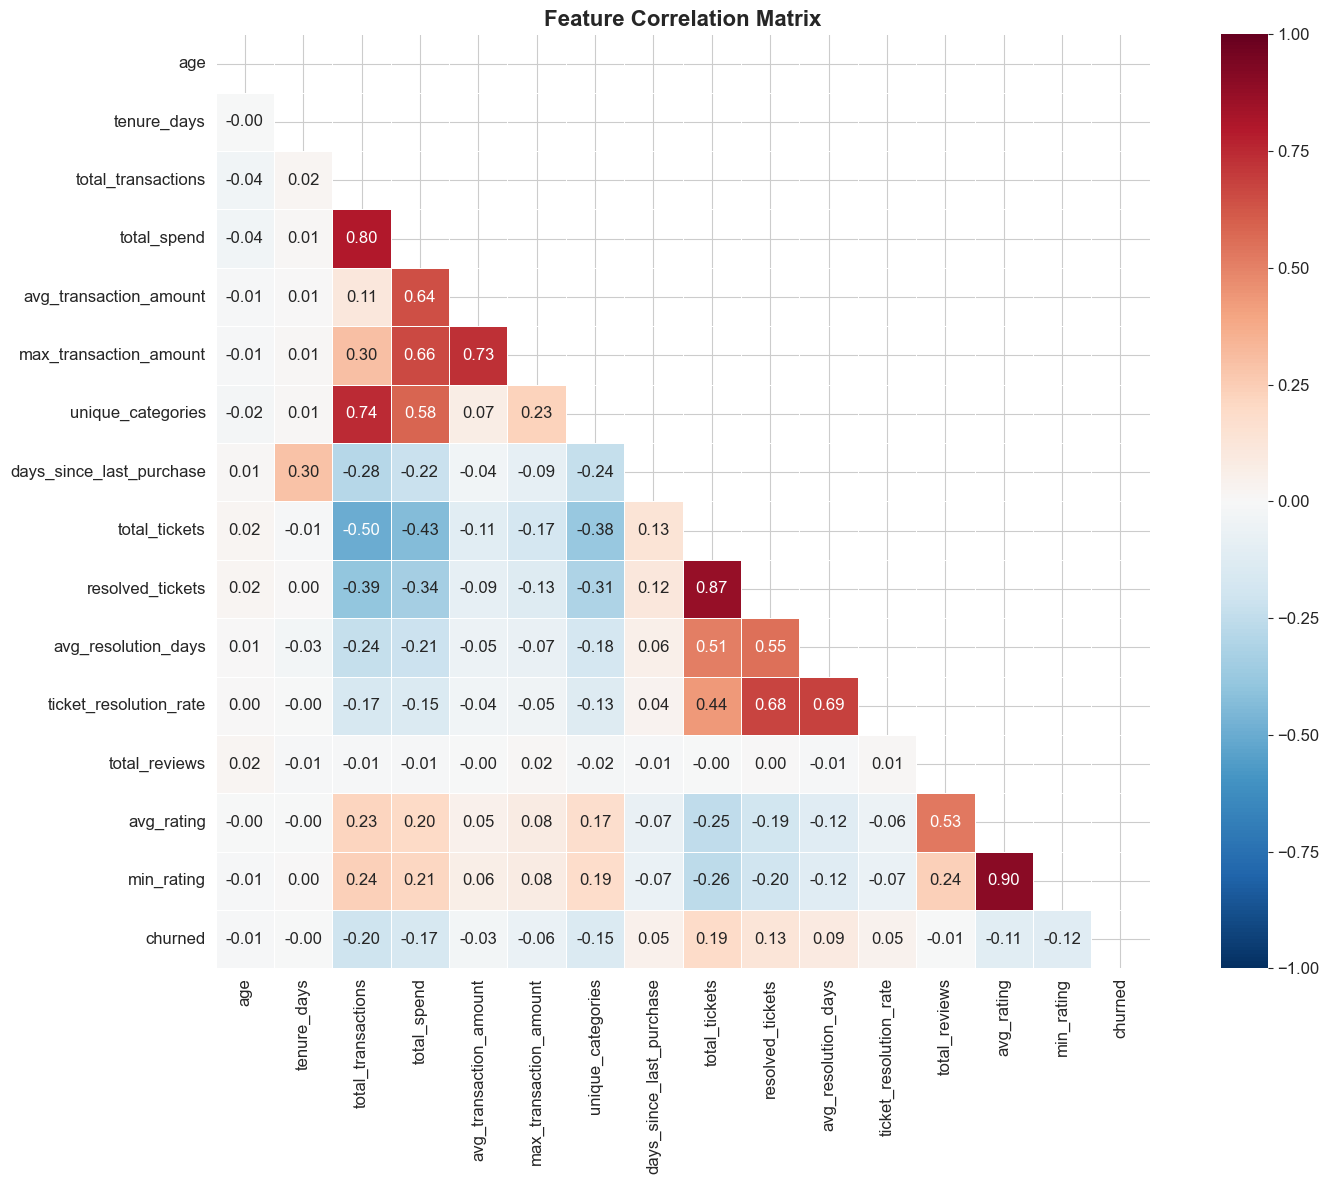


=== Top Features Correlated with Churn ===
  total_transactions             → -0.204  (higher value = LESS churn)
  total_tickets                  → +0.188  (higher value = MORE churn)
  total_spend                    → -0.167  (higher value = LESS churn)
  unique_categories              → -0.145  (higher value = LESS churn)
  resolved_tickets               → +0.129  (higher value = MORE churn)
  min_rating                     → -0.120  (higher value = LESS churn)
  avg_rating                     → -0.112  (higher value = LESS churn)
  avg_resolution_days            → +0.091  (higher value = MORE churn)
  max_transaction_amount         → -0.063  (higher value = LESS churn)
  days_since_last_purchase       → +0.050  (higher value = MORE churn)
  ticket_resolution_rate         → +0.046  (higher value = MORE churn)
  avg_transaction_amount         → -0.030  (higher value = LESS churn)
  age                            → -0.011  (higher value = LESS churn)
  total_reviews                  

In [7]:
# Correlation heatmap
corr_matrix = df[numeric_cols + ['churned']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top correlations with churn specifically
print('\n=== Top Features Correlated with Churn ===')
churn_corr = corr_matrix['churned'].drop('churned').sort_values(key=abs, ascending=False)
for feat, corr in churn_corr.items():
    direction = 'MORE churn' if corr > 0 else 'LESS churn'
    print(f'  {feat:30s} → {corr:+.3f}  (higher value = {direction})')

## 5. Deep Dives: Key Features vs Churn

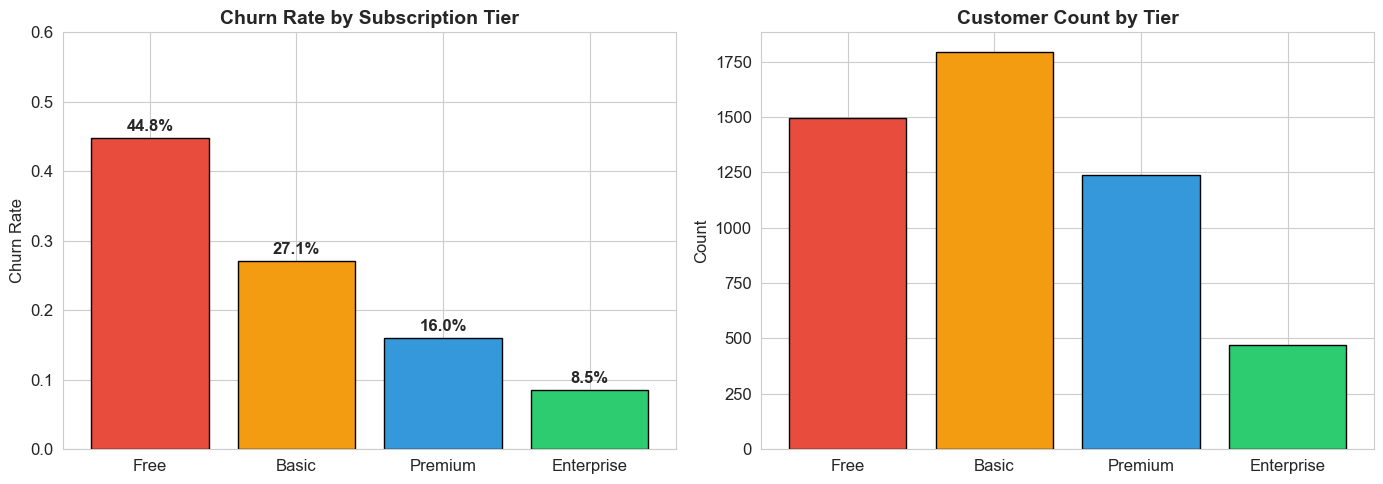

In [8]:
# Churn rate by subscription tier
tier_churn = df.groupby('subscription_tier')['churned'].agg(['mean', 'count']).reset_index()
tier_churn.columns = ['Tier', 'Churn Rate', 'Customer Count']
tier_order = ['Free', 'Basic', 'Premium', 'Enterprise']
tier_churn['Tier'] = pd.Categorical(tier_churn['Tier'], categories=tier_order, ordered=True)
tier_churn = tier_churn.sort_values('Tier')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by tier
bars = axes[0].bar(tier_churn['Tier'], tier_churn['Churn Rate'], 
                    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='black')
axes[0].set_title('Churn Rate by Subscription Tier', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.6)
for bar, rate in zip(bars, tier_churn['Churn Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{rate:.1%}', ha='center', fontweight='bold')

# Customer count by tier
axes[1].bar(tier_churn['Tier'], tier_churn['Customer Count'],
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='black')
axes[1].set_title('Customer Count by Tier', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

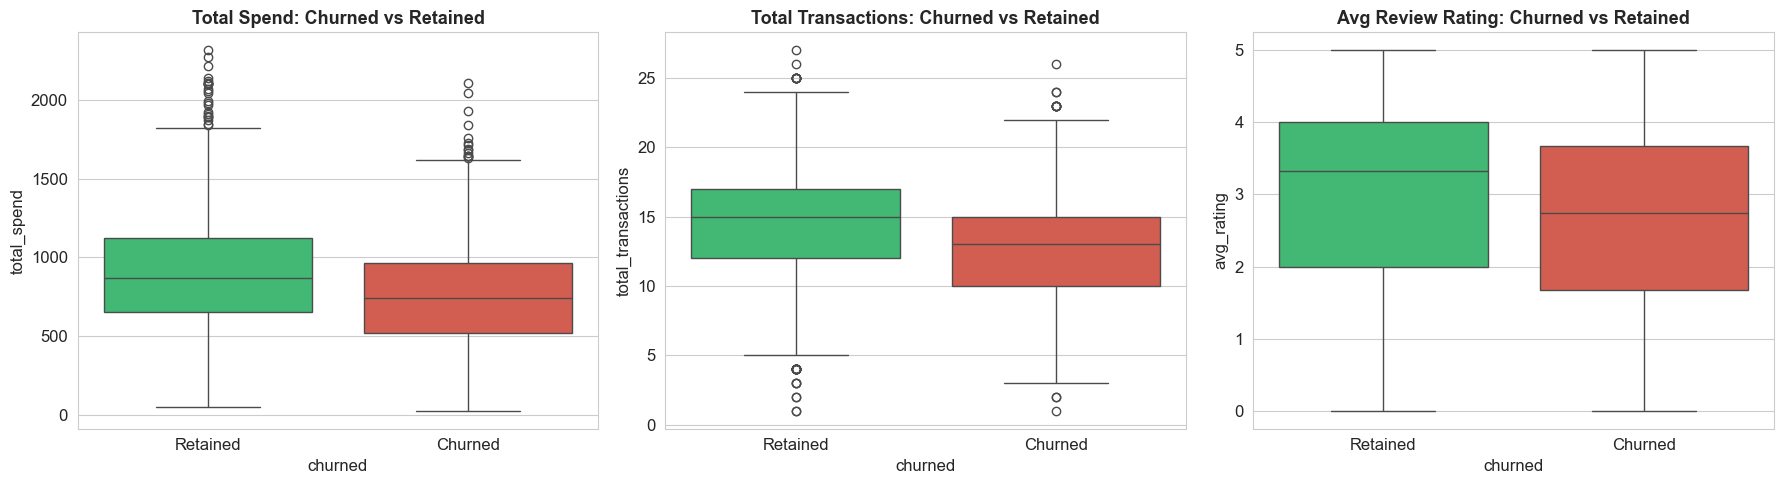

In [9]:
# Spend & engagement comparison: Churned vs Retained
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot: Total Spend
sns.boxplot(data=df, x='churned', y='total_spend', ax=axes[0], palette=colors)
axes[0].set_title('Total Spend: Churned vs Retained', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Retained', 'Churned'])

# Box plot: Total Transactions
sns.boxplot(data=df, x='churned', y='total_transactions', ax=axes[1], palette=colors)
axes[1].set_title('Total Transactions: Churned vs Retained', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Churned'])

# Box plot: Avg Rating
sns.boxplot(data=df, x='churned', y='avg_rating', ax=axes[2], palette=colors)
axes[2].set_title('Avg Review Rating: Churned vs Retained', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('../data/churn_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Interactive scatter: Spend vs Tickets colored by churn
fig = px.scatter(
    df, x='total_spend', y='total_tickets', color='churned',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    labels={'total_spend': 'Total Spend ($)', 'total_tickets': 'Support Tickets', 'churned': 'Churned'},
    title='Customer Segments: Spend vs Support Tickets',
    hover_data=['subscription_tier', 'avg_rating', 'total_transactions'],
    opacity=0.6
)
fig.update_layout(width=900, height=500)
fig.show()

## 6. Key EDA Insights

### What we learned:
1. **Churn rate is ~28%** — moderately imbalanced, but not extreme. We can use standard metrics.
2. **Subscription tier is a strong predictor** — Free tier churns at ~45%, Enterprise at ~8%.
3. **Spending patterns differ dramatically** — churned customers spend significantly less.
4. **Support tickets are a warning signal** — more tickets = higher churn probability.
5. **Review ratings correlate with retention** — happy reviewers stay; angry ones leave.

### Implications for modeling:
- **total_spend, total_transactions, total_tickets, avg_rating** will be our most predictive features
- **subscription_tier** needs one-hot encoding (it's categorical)
- No extreme outliers or data quality issues remain after our pipeline
- The ~28% churn rate means we should track **Precision, Recall, F1, and AUC-ROC** (not just accuracy)